# Data Analysis Notebook

This notebook reproduces the data checks, descriptive analyses, figures, qualitative summaries, and supplementary regression models used in the thesis:

**Designing Uncertainty Aware AI Interfaces: Verbal Hedging and Trust Calibration in Text and Synthetic Speech**

The experiment used a 2 × 2 between-subject design with two factors:

- **Verbal hedging:** no hedge versus hedge
- **Output modality:** text versus synthetic speech

This resulted in four experimental conditions:

- **NH-T:** No hedge + Text
- **H-T:** Hedge + Text
- **NH-S:** No hedge + Speech
- **H-S:** Hedge + Speech

The notebook is organised around the four sub-research questions (SRQ1–SRQ4). Each analysis block explains what is calculated, why it is calculated, and how the output supports the thesis results.

## How to run this notebook

Place this notebook in the same folder as the cleaned CSV files exported from the study server:

- `ai_hedging_clean_participants.csv`
- `ai_hedging_clean_trials_long.csv`
- `ai_hedging_clean_interviews.csv`

Then run the notebook from top to bottom.

The notebook starts from the cleaned datasets rather than from the raw server JSON files. It therefore reproduces the statistical and descriptive analyses reported in the thesis, not the full server-side data extraction process.

## Research questions and hypotheses

The analysis is structured around four sub-research questions (SRQs) and their corresponding hypotheses.

### SRQ1: Verification behaviour

**Research question:** Does verbal hedging selectively increase verification behaviour for incorrect AI answers compared to correct AI answers?

**Hypothesis H1:** Verbal hedging increases verification on incorrect items more than on correct items.

This is tested by comparing verification rates between hedged and non-hedged answers, separately for correct and incorrect AI answers.

### SRQ2: Acceptance of incorrect answers

**Research question:** Does verbal hedging reduce acceptance of incorrect AI answers compared to non-hedged answers?

**Hypothesis H2:** Verbal hedging reduces acceptance of incorrect items.

This is tested by focusing on incorrect-answer trials only. Accepting an incorrect AI answer is interpreted as behavioural overreliance.

### SRQ3: Modality-dependent effect of hedging

**Research question:** Does output modality change the effect of verbal hedging on reliance behaviour?

**Hypothesis H3:** The effect of hedging differs between text and synthetic speech.

This is tested by comparing the effect of hedging in text conditions with the effect of hedging in synthetic speech conditions.

### SRQ4: Adaptation across blocks

**Research question:** Do participants adapt their reliance behaviour across repeated interaction blocks?

**Hypothesis H4:** Reliance behaviour changes across interaction blocks, reflected in changes in verification rate and final accuracy across blocks.

This is tested by comparing verification rate and final accuracy across the three task blocks.

## Python packages and display settings

This block imports the packages used for data handling, visualisation, and supplementary regression modelling. General display settings are defined here so that tables and figures are readable throughout the notebook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Optional, for regression models later
import statsmodels.formula.api as smf

# General display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

plt.rcParams.update({
    "figure.figsize": (9, 5.5),
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "font.size": 11
})

## Loading the cleaned datasets

The analysis uses three cleaned CSV files:

- `ai_hedging_clean_participants.csv`: one row per participant. This file is used for condition balance, manipulation checks, questionnaire outcomes, and post-task measures.
- `ai_hedging_clean_trials_long.csv`: one row per trial. This is the main file for behavioural analysis because it contains verification, acceptance, correctness, final accuracy, block, condition, and timing variables for each trial.
- `ai_hedging_clean_interviews.csv`: one row per participant with open-ended reflection responses. This file is used for descriptive qualitative content analysis.

The printed shapes provide a first check that all files are loaded correctly.

In [2]:
participants = pd.read_csv("ai_hedging_clean_participants.csv")
trials = pd.read_csv("ai_hedging_clean_trials_long.csv")
interviews = pd.read_csv("ai_hedging_clean_interviews.csv")

print("Participants:", participants.shape)
print("Trials:", trials.shape)
print("Interviews:", interviews.shape)

Participants: (72, 108)
Trials: (2160, 46)
Interviews: (72, 18)


## Data quality checks

Before analysing the research questions, the dataset is checked against the expected experimental design. The final sample should contain 72 participants, with 18 participants in each of the four experimental conditions. Each participant completed 30 trials, resulting in 2160 trial-level observations in total.

These checks are important because all later behavioural rates depend on complete trial-level data and balanced condition assignment.

In [3]:
# Number of unique participants
n_participants = participants["participant_id"].nunique()
n_trials = len(trials)

print("Number of participants:", n_participants)
print("Number of trials:", n_trials)

# Check condition balance
condition_counts = participants.groupby(["condition", "condition_label"]).size().reset_index(name="n")
condition_counts

Number of participants: 72
Number of trials: 2160


,condition,condition_label,n
0,C1,No hedge + Text,18
1,C2,Hedge + Text,18
2,C3,No hedge + Speech,18
3,C4,Hedge + Speech,18


The final dataset contains 72 participants and 2160 trial-level observations, calculated as 72 participants × 30 trials. The design is balanced, with 18 participants in each of the four experimental conditions.

The trial-level observations are used for behavioural analyses, but they are not fully independent because each participant completed multiple trials and each item appeared across participants. This is why the main analysis is descriptive and the regression models are treated as supplementary statistical checks.

## Figure styling and helper functions

The following settings define a fixed condition order and a consistent pastel colour palette for all figures. This helps keep the visualisations comparable across SRQ1–SRQ4.

Two helper functions are also defined:

- `add_percentage_labels()` adds percentage labels above bars.
- `clean_axis()` applies a simple academic figure style.

In [4]:
# Fixed order for figures
condition_order = [
    "No hedge + Text",
    "Hedge + Text",
    "No hedge + Speech",
    "Hedge + Speech"
]

# Pastel colours for consistent visualisation
pastel_colors = {
    "No hedge + Text": "#A8DADC",
    "Hedge + Text": "#F4A261",
    "No hedge + Speech": "#B7E4C7",
    "Hedge + Speech": "#CDB4DB"
}

# Ensure important variables are numeric
numeric_cols = [
    "verified", "accepted", "final_accuracy", "overreliance_error",
    "underreliance_error", "correctness", "hedging", "modality",
    "block", "decision_time_sec"
]

for col in numeric_cols:
    if col in trials.columns:
        trials[col] = pd.to_numeric(trials[col], errors="coerce")

In [5]:
def add_percentage_labels(ax, bars, offset=0.01):
    """Add percentage labels above bars."""
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + offset,
            f"{height * 100:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )


def clean_axis(ax):
    """Apply clean academic figure styling."""
    ax.grid(axis="y", linestyle="--", alpha=0.35)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

## Overall condition summary

This table provides a descriptive overview of the main behavioural outcomes per experimental condition. It is used as a first check of the overall behavioural pattern before answering the separate sub-research questions.

The table includes verification rate, acceptance rate, final accuracy, overreliance errors, underreliance errors, and mean decision time. These values are descriptive and are not used as standalone statistical tests.

In [6]:
condition_summary = trials.groupby("condition_label").agg(
    n_trials=("participant_id", "count"),
    n_participants=("participant_id", "nunique"),
    verify_rate=("verified", "mean"),
    accept_rate=("accepted", "mean"),
    final_accuracy=("final_accuracy", "mean"),
    overreliance_rate=("overreliance_error", "mean"),
    underreliance_rate=("underreliance_error", "mean"),
    mean_decision_time_sec=("decision_time_sec", "mean")
).reset_index()

condition_summary["condition_label"] = pd.Categorical(
    condition_summary["condition_label"],
    categories=condition_order,
    ordered=True
)

condition_summary = condition_summary.sort_values("condition_label")

# Add percentage columns for readable reporting
for col in ["verify_rate", "accept_rate", "final_accuracy", "overreliance_rate", "underreliance_rate"]:
    condition_summary[col + "_percent"] = (condition_summary[col] * 100).round(1)

condition_summary["mean_decision_time_sec"] = condition_summary["mean_decision_time_sec"].round(2)

condition_summary

,condition_label,n_trials,n_participants,verify_rate,accept_rate,final_accuracy,overreliance_rate,underreliance_rate,mean_decision_time_sec,verify_rate_percent,accept_rate_percent,final_accuracy_percent,overreliance_rate_percent,underreliance_rate_percent
3,No hedge + Text,540,18,0.377778,0.705556,0.861111,0.072222,0.066667,12.29,37.8,70.6,86.1,7.2,6.7
1,Hedge + Text,540,18,0.435185,0.698148,0.864815,0.066667,0.068519,13.63,43.5,69.8,86.5,6.7,6.9
2,No hedge + Speech,540,18,0.301852,0.696296,0.825926,0.085185,0.088889,8.46,30.2,69.6,82.6,8.5,8.9
0,Hedge + Speech,540,18,0.272222,0.674074,0.803704,0.085185,0.111111,8.01,27.2,67.4,80.4,8.5,11.1


The condition summary shows that each condition contains 540 trial-level observations, corresponding to 18 participants × 30 trials. This confirms that the condition-level comparisons are based on balanced groups.

# Manipulation check

Before answering the research questions, the manipulation check was used to assess whether participants perceived hedged answers as more uncertain and less certain than non-hedged answers.

This check is important because the behavioural effects of hedging can only be interpreted meaningfully if the wording manipulation was perceived as intended. If participants did not notice any difference in perceived certainty, weak behavioural effects could be explained by a failed manipulation. If the manipulation check does show a difference, the later behavioural analyses can examine whether perceived uncertainty also translated into calibrated reliance behaviour.

In [7]:
# Make sure relevant participant-level columns are numeric
manipulation_cols = [
    "manipulation_uncertainty",
    "manipulation_certainty",
    "PT1",
    "PT2"
]

for col in manipulation_cols:
    if col in participants.columns:
        participants[col] = pd.to_numeric(participants[col], errors="coerce")

# Manipulation check: no hedge vs hedge
# PT1 and PT2 are study-specific post-task items that mirror perceived uncertainty/certainty.
manipulation_check = participants.groupby("hedging").agg(
    n_participants=("participant_id", "nunique"),

    perceived_uncertainty_M=("manipulation_uncertainty", "mean"),
    perceived_uncertainty_SD=("manipulation_uncertainty", "std"),

    perceived_certainty_M=("manipulation_certainty", "mean"),
    perceived_certainty_SD=("manipulation_certainty", "std"),

    posttask_uncertainty_M=("PT1", "mean"),
    posttask_uncertainty_SD=("PT1", "std"),

    posttask_certainty_M=("PT2", "mean"),
    posttask_certainty_SD=("PT2", "std")
).reset_index()

manipulation_check["hedging_label"] = manipulation_check["hedging"].map({
    0: "No hedge",
    1: "Hedge"
})

manipulation_check = manipulation_check[
    [
        "hedging_label",
        "n_participants",
        "perceived_uncertainty_M",
        "perceived_uncertainty_SD",
        "perceived_certainty_M",
        "perceived_certainty_SD",
        "posttask_uncertainty_M",
        "posttask_uncertainty_SD",
        "posttask_certainty_M",
        "posttask_certainty_SD"
    ]
]

manipulation_check.round(2)

,hedging_label,n_participants,perceived_uncertainty_M,perceived_uncertainty_SD,perceived_certainty_M,perceived_certainty_SD,posttask_uncertainty_M,posttask_uncertainty_SD,posttask_certainty_M,posttask_certainty_SD
0,No hedge,36,2.50,1.42,5.75,1.16,2.89,1.67,5.58,1.38
1,Hedge,36,4.39,1.79,4.00,1.74,4.61,1.76,4.17,1.76


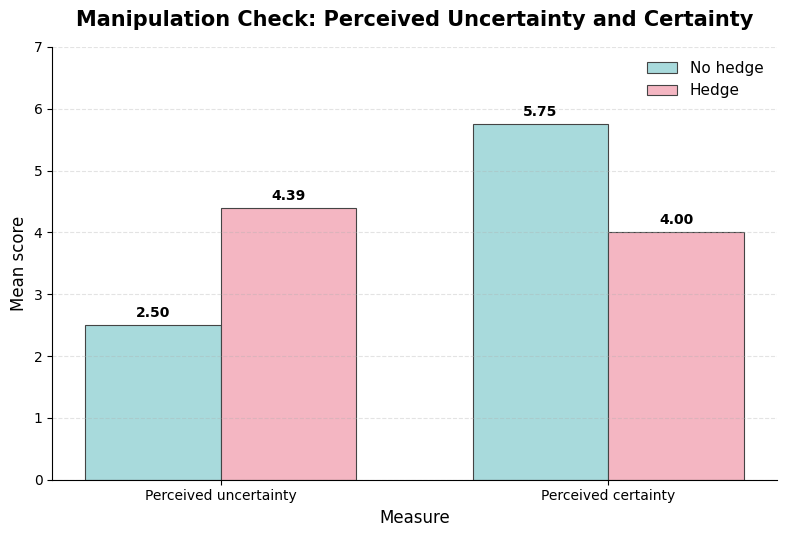

In [8]:
# Prepare data for the manipulation-check figure
manip_plot = manipulation_check.melt(
    id_vars="hedging_label",
    value_vars=["perceived_uncertainty_M", "perceived_certainty_M"],
    var_name="measure",
    value_name="mean_score"
)

manip_plot["measure"] = manip_plot["measure"].map({
    "perceived_uncertainty_M": "Perceived uncertainty",
    "perceived_certainty_M": "Perceived certainty"
})

fig, ax = plt.subplots(figsize=(8, 5.5))

x = np.arange(2)
width = 0.35

measure_order = ["Perceived uncertainty", "Perceived certainty"]

manip_plot["measure"] = pd.Categorical(
    manip_plot["measure"],
    categories=measure_order,
    ordered=True
)

manip_plot = manip_plot.sort_values(["hedging_label", "measure"])

no_hedge_values = (
    manip_plot[manip_plot["hedging_label"] == "No hedge"]
    .sort_values("measure")["mean_score"]
    .values
)

hedge_values = (
    manip_plot[manip_plot["hedging_label"] == "Hedge"]
    .sort_values("measure")["mean_score"]
    .values
)


bars1 = ax.bar(
    x - width/2,
    no_hedge_values,
    width,
    label="No hedge",
    color="#A8DADC",
    edgecolor="#444444",
    linewidth=0.8
)

bars2 = ax.bar(
    x + width/2,
    hedge_values,
    width,
    label="Hedge",
    color="#F4B6C2",
    edgecolor="#444444",
    linewidth=0.8
)

ax.set_title("Manipulation Check: Perceived Uncertainty and Certainty", pad=15, fontweight="bold")
ax.set_xlabel("Measure")
ax.set_ylabel("Mean score")
ax.set_xticks(x)
ax.set_xticklabels(["Perceived uncertainty", "Perceived certainty"])
ax.set_ylim(0, 7)
ax.legend(frameon=False)

clean_axis(ax)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.08,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

plt.tight_layout()
plt.savefig("manipulation_check_uncertainty_certainty.png", dpi=300, bbox_inches="tight")
plt.show()

## Manipulation check conclusion

The manipulation check was used to verify whether the hedging manipulation was perceived as intended. Participants in the hedge condition reported higher perceived uncertainty than participants in the no-hedge condition. Perceived uncertainty increased from M = 2.50, SD = 1.42 in the no-hedge condition to M = 4.39, SD = 1.79 in the hedge condition.

The opposite pattern appeared for perceived certainty. Participants in the no-hedge condition reported higher perceived certainty, M = 5.75, SD = 1.16, than participants in the hedge condition, M = 4.00, SD = 1.74.

The study-specific post-task items showed a similar descriptive pattern. Post-task uncertainty was higher in the hedge condition, M = 4.61, SD = 1.76, than in the no-hedge condition, M = 2.89, SD = 1.67. Post-task certainty was lower in the hedge condition, M = 4.17, SD = 1.76, than in the no-hedge condition, M = 5.58, SD = 1.38.

This suggests that the hedging manipulation was perceived as intended. The behavioural analyses below examine whether this perceived uncertainty also translated into calibrated reliance behaviour.

# SRQ1: Verification behaviour

## Research question

**Does verbal hedging selectively increase verification behaviour for incorrect AI answers compared to correct AI answers?**

## Hypothesis

**H1:** Verbal hedging increases verification on incorrect items more than on correct items.

This question is tested by comparing verification rates between hedged and non-hedged answers, separately for correct and incorrect AI answers. If hedging supports calibration, the hedging-related increase should be larger for incorrect answers than for correct answers. If hedging increases verification equally for correct and incorrect answers, this would suggest general scepticism rather than selective calibration.

In [9]:
srq1_table = trials.groupby(["hedging", "correctness"]).agg(
    verify_rate=("verified", "mean"),
    n_trials=("participant_id", "count")
).reset_index()

srq1_table["hedging_label"] = srq1_table["hedging"].map({
    0: "No hedge",
    1: "Hedge"
})

srq1_table["answer_type"] = srq1_table["correctness"].map({
    0: "Incorrect answer",
    1: "Correct answer"
})

srq1_table["verify_rate_percent"] = (srq1_table["verify_rate"] * 100).round(1)

srq1_table = srq1_table[
    [
        "hedging_label",
        "answer_type",
        "verify_rate",
        "verify_rate_percent",
        "n_trials"
    ]
]

srq1_table

,hedging_label,answer_type,verify_rate,verify_rate_percent,n_trials
0,No hedge,Incorrect answer,0.422840,42.3,324
1,No hedge,Correct answer,0.304233,30.4,756
2,Hedge,Incorrect answer,0.435185,43.5,324
3,Hedge,Correct answer,0.318783,31.9,756


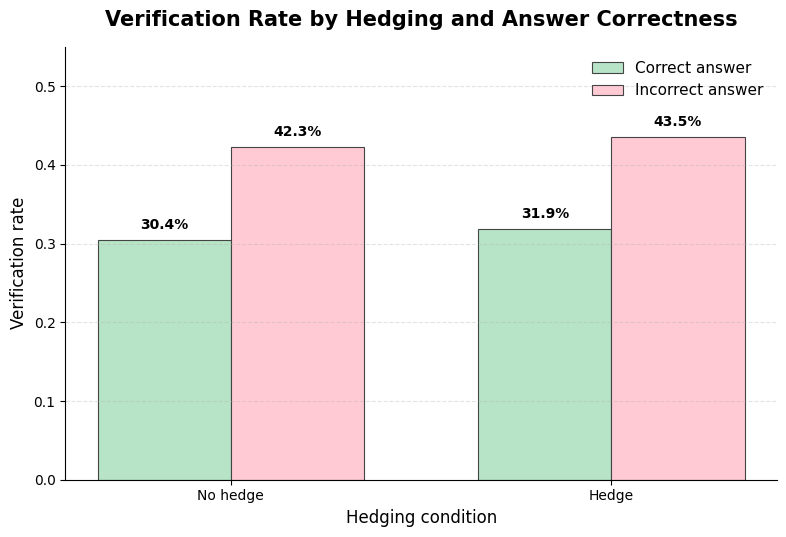

In [10]:
srq1_plot = srq1_table.pivot(
    index="hedging_label",
    columns="answer_type",
    values="verify_rate"
).reindex(["No hedge", "Hedge"])

x = np.arange(len(srq1_plot.index))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5.5))

bars_correct = ax.bar(
    x - width / 2,
    srq1_plot["Correct answer"],
    width,
    label="Correct answer",
    color="#B7E4C7",
    edgecolor="#444444",
    linewidth=0.8
)

bars_incorrect = ax.bar(
    x + width / 2,
    srq1_plot["Incorrect answer"],
    width,
    label="Incorrect answer",
    color="#FFCAD4",
    edgecolor="#444444",
    linewidth=0.8
)

ax.set_title("Verification Rate by Hedging and Answer Correctness", pad=15, fontweight="bold")
ax.set_xlabel("Hedging condition")
ax.set_ylabel("Verification rate")
ax.set_xticks(x)
ax.set_xticklabels(srq1_plot.index)
ax.set_ylim(0, 0.55)
ax.legend(frameon=False)

clean_axis(ax)
add_percentage_labels(ax, bars_correct)
add_percentage_labels(ax, bars_incorrect)

plt.tight_layout()
plt.savefig("srq1_verification_by_hedging_and_correctness.png", dpi=300, bbox_inches="tight")
plt.show()

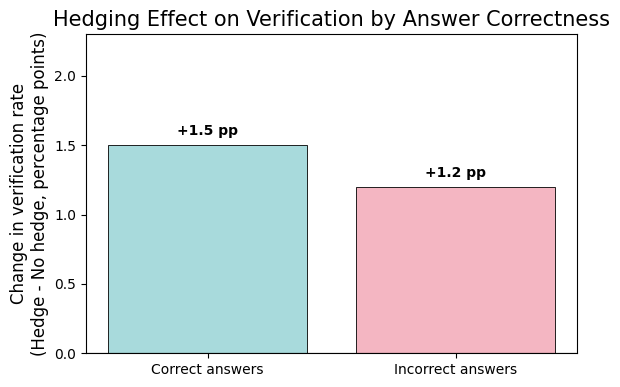

hedging_label,Hedge,No hedge,hedging_effect_pp
answer_type,,,
Correct answer,31.9,30.4,1.5
Incorrect answer,43.5,42.3,1.2


In [11]:
# Calculate the hedging effect directly from the SRQ1 table.
# This shows whether the hedging-related increase was larger for incorrect answers than for correct answers.

srq1_effect = srq1_table.pivot(
    index="answer_type",
    columns="hedging_label",
    values="verify_rate_percent"
)

srq1_effect["hedging_effect_pp"] = srq1_effect["Hedge"] - srq1_effect["No hedge"]

effects = [
    srq1_effect.loc["Correct answer", "hedging_effect_pp"],
    srq1_effect.loc["Incorrect answer", "hedging_effect_pp"]
]

labels = ["Correct answers", "Incorrect answers"]
pastel_colours = ["#A8DADC", "#F4B6C2"]

plt.figure(figsize=(6, 4))
bars = plt.bar(
    labels,
    effects,
    color=pastel_colours,
    edgecolor="black",
    linewidth=0.6
)

plt.ylabel("Change in verification rate\n(Hedge - No hedge, percentage points)")
plt.title("Hedging Effect on Verification by Answer Correctness")
plt.axhline(0, color="black", linewidth=0.8)

for bar, value in zip(bars, effects):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.05,
        f"+{value:.1f} pp",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.ylim(0, max(effects) + 0.8)
plt.tight_layout()
plt.savefig("hedging_effect_verification_correctness.png", dpi=300, bbox_inches="tight")
plt.show()

srq1_effect

## SRQ1 conclusion

The SRQ1 analysis examines whether hedging selectively increased verification for incorrect-answer trials. Incorrect-answer trials were verified more often than correct-answer trials in both hedging conditions. This indicates that answer correctness was more clearly associated with verification behaviour than hedging itself.

The hedging-related change was small. Verification increased by 1.2 percentage points for incorrect answers, from 42.3% to 43.5%, and by 1.5 percentage points for correct answers, from 30.4% to 31.9%. Because the increase was not larger for incorrect answers than for correct answers, the pattern does not indicate a selective verification effect for incorrect answers.

This output is used for Section 4.3 of the thesis. H1 is therefore only weakly supported.

# SRQ2: Acceptance of incorrect answers

## Research question

**Does verbal hedging reduce acceptance of incorrect AI answers compared to non-hedged answers?**

## Hypothesis

**H2:** Verbal hedging reduces acceptance of incorrect items.

This analysis focuses on incorrect-answer trials only. Acceptance of an incorrect AI answer is interpreted as behavioural overreliance. The acceptance rate for incorrect answers is calculated separately for each experimental condition.

In [12]:
srq2_table = trials[trials["correctness"] == 0].groupby(
    ["condition_label", "hedging", "modality"]
).agg(
    accept_incorrect_rate=("accepted", "mean"),
    overreliance_rate=("overreliance_error", "mean"),
    n_incorrect_trials=("participant_id", "count")
).reset_index()

srq2_table["hedging_label"] = srq2_table["hedging"].map({
    0: "No hedge",
    1: "Hedge"
})

srq2_table["modality_label"] = srq2_table["modality"].map({
    0: "Text",
    1: "Speech"
})

srq2_table["condition_label"] = pd.Categorical(
    srq2_table["condition_label"],
    categories=condition_order,
    ordered=True
)

srq2_table = srq2_table.sort_values("condition_label")

srq2_table["accept_incorrect_percent"] = (srq2_table["accept_incorrect_rate"] * 100).round(1)
srq2_table["overreliance_percent"] = (srq2_table["overreliance_rate"] * 100).round(1)

srq2_table[
    [
        "condition_label",
        "hedging_label",
        "modality_label",
        "accept_incorrect_rate",
        "accept_incorrect_percent",
        "overreliance_rate",
        "overreliance_percent",
        "n_incorrect_trials"
    ]
]

,condition_label,hedging_label,modality_label,accept_incorrect_rate,accept_incorrect_percent,overreliance_rate,overreliance_percent,n_incorrect_trials
3,No hedge + Text,No hedge,Text,0.240741,24.1,0.240741,24.1,162
1,Hedge + Text,Hedge,Text,0.222222,22.2,0.222222,22.2,162
2,No hedge + Speech,No hedge,Speech,0.283951,28.4,0.283951,28.4,162
0,Hedge + Speech,Hedge,Speech,0.283951,28.4,0.283951,28.4,162


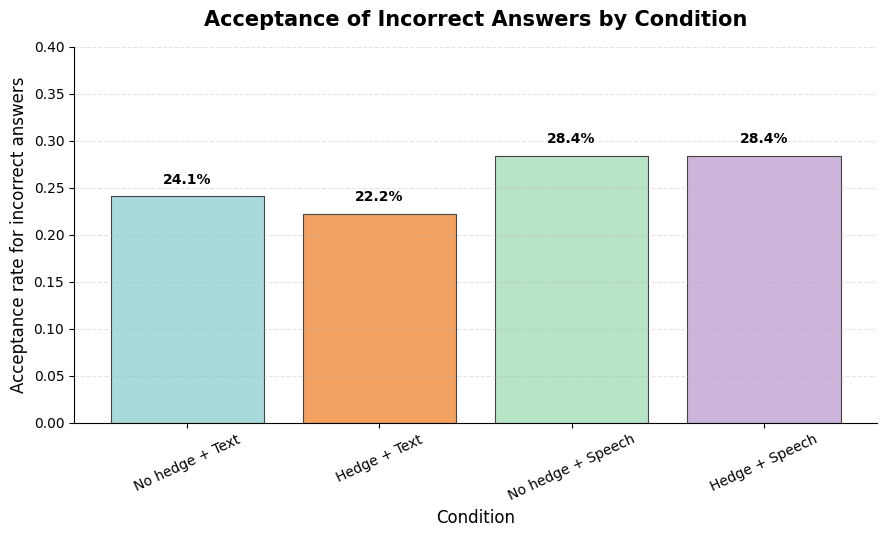

In [13]:
fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.bar(
    srq2_table["condition_label"].astype(str),
    srq2_table["accept_incorrect_rate"],
    color=[pastel_colors[c] for c in srq2_table["condition_label"].astype(str)],
    edgecolor="#444444",
    linewidth=0.8
)

ax.set_title("Acceptance of Incorrect Answers by Condition", pad=15, fontweight="bold")
ax.set_xlabel("Condition")
ax.set_ylabel("Acceptance rate for incorrect answers")
ax.set_ylim(0, 0.40)
ax.tick_params(axis="x", rotation=25)

clean_axis(ax)
add_percentage_labels(ax, bars)

plt.tight_layout()
plt.savefig("srq2_acceptance_incorrect_answers_by_condition.png", dpi=300, bbox_inches="tight")
plt.show()

## SRQ2 conclusion

The SRQ2 analysis focuses only on incorrect-answer trials, because accepting an incorrect AI answer is interpreted as behavioural overreliance.

The evidence for SRQ2 is limited. In the text conditions, hedging reduced acceptance of incorrect answers from 24.1% in NH-T to 22.2% in H-T. This is a reduction of 1.9 percentage points and is in the expected direction, but the descriptive difference is small.

In the speech conditions, hedging did not reduce incorrect-answer acceptance. Both NH-S and H-S showed an incorrect-answer acceptance rate of 28.4%.

This output is used for Section 4.4 of the thesis. H2 is therefore only weakly supported.

# SRQ3: Modality-dependent effect of hedging

## Research question

**Does output modality change the effect of verbal hedging on reliance behaviour?**

## Hypothesis

**H3:** The effect of hedging differs between text and synthetic speech.

This analysis examines whether the behavioural effect of hedging depends on output modality. In other words, it tests whether hedging has the same association with verification and final accuracy in text and synthetic speech conditions.

In [14]:
srq3_table = trials.groupby(["hedging", "modality", "condition_label"]).agg(
    n_trials=("participant_id", "count"),
    n_participants=("participant_id", "nunique"),
    verify_rate=("verified", "mean"),
    accept_rate=("accepted", "mean"),
    final_accuracy=("final_accuracy", "mean"),
    overreliance_rate=("overreliance_error", "mean")
).reset_index()

srq3_table["hedging_label"] = srq3_table["hedging"].map({
    0: "No hedge",
    1: "Hedge"
})

srq3_table["modality_label"] = srq3_table["modality"].map({
    0: "Text",
    1: "Speech"
})

srq3_table["condition_label"] = pd.Categorical(
    srq3_table["condition_label"],
    categories=condition_order,
    ordered=True
)

srq3_table = srq3_table.sort_values("condition_label")

for col in ["verify_rate", "accept_rate", "final_accuracy", "overreliance_rate"]:
    srq3_table[col + "_percent"] = (srq3_table[col] * 100).round(1)

srq3_table[[
    "condition_label",
    "hedging_label",
    "modality_label",
    "n_participants",
    "verify_rate_percent",
    "accept_rate_percent",
    "final_accuracy_percent",
    "overreliance_rate_percent"
]]

,condition_label,hedging_label,modality_label,n_participants,verify_rate_percent,accept_rate_percent,final_accuracy_percent,overreliance_rate_percent
0,No hedge + Text,No hedge,Text,18,37.8,70.6,86.1,7.2
2,Hedge + Text,Hedge,Text,18,43.5,69.8,86.5,6.7
1,No hedge + Speech,No hedge,Speech,18,30.2,69.6,82.6,8.5
3,Hedge + Speech,Hedge,Speech,18,27.2,67.4,80.4,8.5


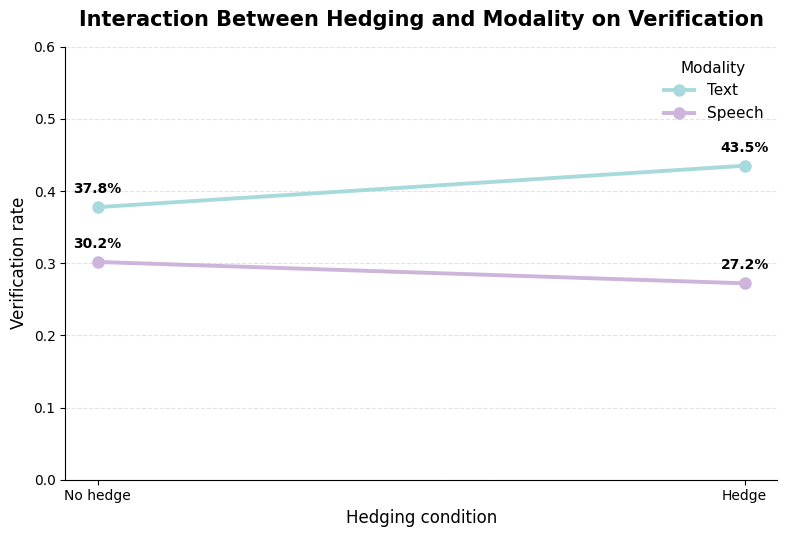

In [15]:
srq3_interaction = trials.groupby(["hedging", "modality"]).agg(
    verify_rate=("verified", "mean"),
    n_trials=("participant_id", "count")
).reset_index()

srq3_interaction["hedging_label"] = srq3_interaction["hedging"].map({
    0: "No hedge",
    1: "Hedge"
})

srq3_interaction["modality_label"] = srq3_interaction["modality"].map({
    0: "Text",
    1: "Speech"
})

hedging_order = ["No hedge", "Hedge"]

fig, ax = plt.subplots(figsize=(8, 5.5))

colors = {
    "Text": "#A8DADC",
    "Speech": "#CDB4DB"
}

for modality in ["Text", "Speech"]:
    subset = srq3_interaction[srq3_interaction["modality_label"] == modality].copy()
    subset["hedging_label"] = pd.Categorical(
        subset["hedging_label"],
        categories=hedging_order,
        ordered=True
    )
    subset = subset.sort_values("hedging_label")
    
    ax.plot(
        subset["hedging_label"],
        subset["verify_rate"],
        marker="o",
        linewidth=2.8,
        markersize=8,
        label=modality,
        color=colors[modality]
    )
    
    for _, row in subset.iterrows():
        ax.text(
            row["hedging_label"],
            row["verify_rate"] + 0.015,
            f"{row['verify_rate'] * 100:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

ax.set_title("Interaction Between Hedging and Modality on Verification", pad=15, fontweight="bold")
ax.set_xlabel("Hedging condition")
ax.set_ylabel("Verification rate")
ax.set_ylim(0, 0.6)
ax.legend(frameon=False, title="Modality")

clean_axis(ax)

plt.tight_layout()
plt.savefig("srq3_interaction_hedging_modality_verification.png", dpi=300, bbox_inches="tight")
plt.show()

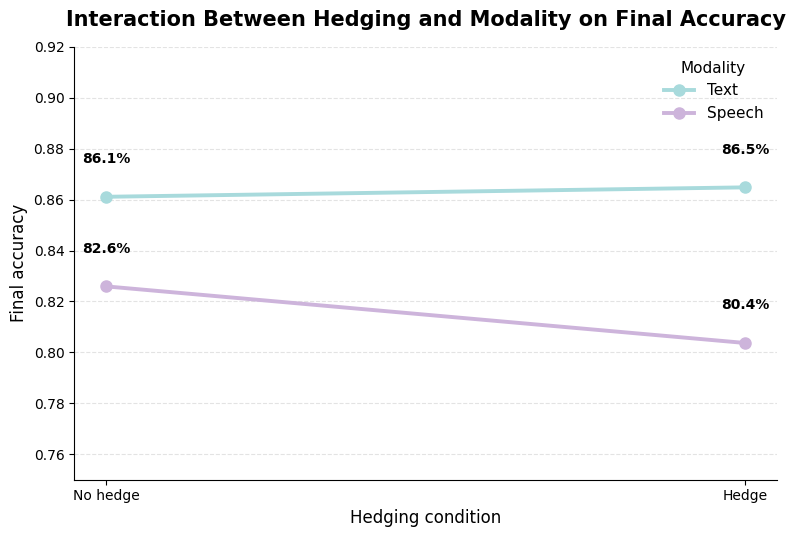

In [16]:
srq3_accuracy = trials.groupby(["hedging", "modality"]).agg(
    final_accuracy=("final_accuracy", "mean"),
    n_trials=("participant_id", "count")
).reset_index()

srq3_accuracy["hedging_label"] = srq3_accuracy["hedging"].map({
    0: "No hedge",
    1: "Hedge"
})

srq3_accuracy["modality_label"] = srq3_accuracy["modality"].map({
    0: "Text",
    1: "Speech"
})

fig, ax = plt.subplots(figsize=(8, 5.5))

for modality in ["Text", "Speech"]:
    subset = srq3_accuracy[srq3_accuracy["modality_label"] == modality].copy()
    subset["hedging_label"] = pd.Categorical(
        subset["hedging_label"],
        categories=hedging_order,
        ordered=True
    )
    subset = subset.sort_values("hedging_label")
    
    ax.plot(
        subset["hedging_label"],
        subset["final_accuracy"],
        marker="o",
        linewidth=2.8,
        markersize=8,
        label=modality,
        color=colors[modality]
    )
    
    for _, row in subset.iterrows():
        ax.text(
            row["hedging_label"],
            row["final_accuracy"] + 0.012,
            f"{row['final_accuracy'] * 100:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

ax.set_title("Interaction Between Hedging and Modality on Final Accuracy", pad=15, fontweight="bold")
ax.set_xlabel("Hedging condition")
ax.set_ylabel("Final accuracy")
ax.set_ylim(0.75, 0.92)
ax.legend(frameon=False, title="Modality")

clean_axis(ax)

plt.tight_layout()
plt.savefig("srq3_interaction_hedging_modality_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

## SRQ3 conclusion

The SRQ3 analysis examines whether the effect of hedging differed between text and synthetic speech. The descriptive pattern shows that hedging did not work in the same way across modalities.

In the text conditions, hedging increased verification from 37.8% in NH-T to 43.5% in H-T. In the speech conditions, verification decreased from 30.2% in NH-S to 27.2% in H-S. This suggests that the hedging cue was more effective as a visible written cue than as a spoken cue in this experimental setup.

The performance measures showed a similar modality-related pattern. Final accuracy was higher in the text conditions than in the speech conditions, and H-S produced the lowest final accuracy of the four conditions.

The supplementary logistic regression model later in the notebook tests this pattern statistically and shows a significant hedging by modality interaction for verification behaviour. This output is used for Section 4.5 of the thesis. H3 is supported in this experimental setup.

# SRQ4: Adaptation across blocks

## Research question

**Do participants adapt their reliance behaviour across repeated interaction blocks?**

## Hypothesis

**H4:** Reliance behaviour changes across interaction blocks, reflected in changes in verification rate and final accuracy across blocks.

This analysis examines whether verification, acceptance, final accuracy, and decision time changed across block 1, block 2, and block 3. Because the blocks occurred within one session, the results are interpreted as within-session block-level changes rather than as long-term adaptation.

In [17]:
srq4_table = trials.groupby(["condition_label", "block"]).agg(
    n_trials=("participant_id", "count"),
    n_participants=("participant_id", "nunique"),
    verify_rate=("verified", "mean"),
    accept_rate=("accepted", "mean"),
    final_accuracy=("final_accuracy", "mean"),
    mean_decision_time_sec=("decision_time_sec", "mean")
).reset_index()

for col in ["verify_rate", "accept_rate", "final_accuracy"]:
    srq4_table[col + "_percent"] = (srq4_table[col] * 100).round(1)

srq4_table["mean_decision_time_sec"] = srq4_table["mean_decision_time_sec"].round(2)

srq4_table["condition_label"] = pd.Categorical(
    srq4_table["condition_label"],
    categories=condition_order,
    ordered=True
)

srq4_table = srq4_table.sort_values(["condition_label", "block"])

srq4_table[[
    "condition_label",
    "block",
    "n_participants",
    "verify_rate_percent",
    "accept_rate_percent",
    "final_accuracy_percent",
    "mean_decision_time_sec"
]]

,condition_label,block,n_participants,verify_rate_percent,accept_rate_percent,final_accuracy_percent,mean_decision_time_sec
9,No hedge + Text,1,18,40.0,70.0,86.7,16.05
10,No hedge + Text,2,18,36.1,71.7,82.8,11.03
11,No hedge + Text,3,18,37.2,70.0,88.9,9.79
3,Hedge + Text,1,18,46.7,69.4,82.8,16.02
4,Hedge + Text,2,18,43.3,71.1,90.0,12.17
5,Hedge + Text,3,18,40.6,68.9,86.7,12.70
6,No hedge + Speech,1,18,26.7,67.8,80.0,10.60
7,No hedge + Speech,2,18,27.2,70.0,83.3,7.00
8,No hedge + Speech,3,18,36.7,71.1,84.4,7.79
0,Hedge + Speech,1,18,26.1,69.4,78.3,9.83


In [18]:
srq4_overall = trials.groupby("block").agg(
    n_trials=("participant_id", "count"),
    n_participants=("participant_id", "nunique"),
    verify_rate=("verified", "mean"),
    accept_rate=("accepted", "mean"),
    final_accuracy=("final_accuracy", "mean"),
    mean_decision_time_sec=("decision_time_sec", "mean")
).reset_index()

for col in ["verify_rate", "accept_rate", "final_accuracy"]:
    srq4_overall[col + "_percent"] = (srq4_overall[col] * 100).round(1)

srq4_overall["mean_decision_time_sec"] = srq4_overall["mean_decision_time_sec"].round(2)

srq4_overall[[
    "block",
    "n_participants",
    "verify_rate_percent",
    "accept_rate_percent",
    "final_accuracy_percent",
    "mean_decision_time_sec"
]]

,block,n_participants,verify_rate_percent,accept_rate_percent,final_accuracy_percent,mean_decision_time_sec
0,1,72,34.9,69.2,81.9,13.13
1,2,72,32.2,69.2,84.7,9.23
2,3,72,36.9,69.7,85.0,9.44


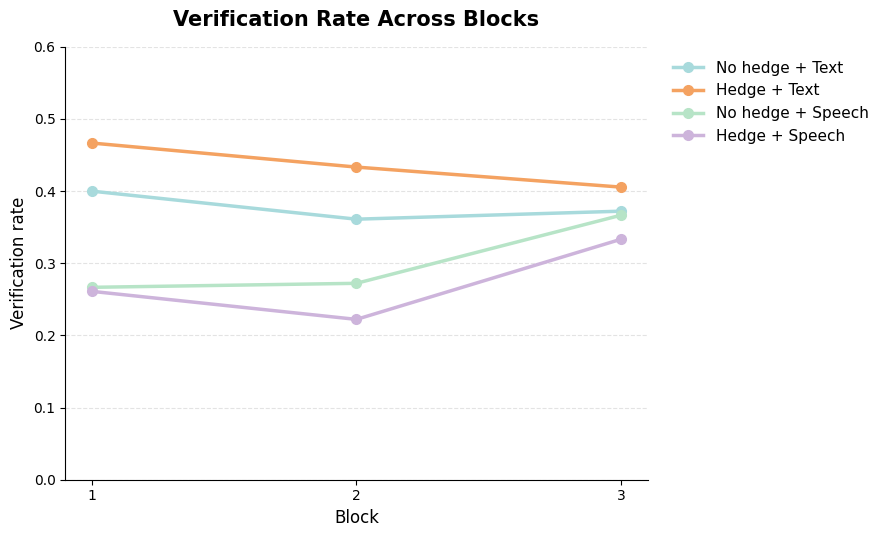

In [19]:
fig, ax = plt.subplots(figsize=(9, 5.5))

for condition in condition_order:
    subset = srq4_table[srq4_table["condition_label"] == condition]
    
    ax.plot(
        subset["block"],
        subset["verify_rate"],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=condition,
        color=pastel_colors[condition]
    )

ax.set_title("Verification Rate Across Blocks", pad=15, fontweight="bold")
ax.set_xlabel("Block")
ax.set_ylabel("Verification rate")
ax.set_xticks([1, 2, 3])
ax.set_ylim(0, 0.60)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

clean_axis(ax)

plt.tight_layout()
plt.savefig("srq4_verification_rate_across_blocks.png", dpi=300, bbox_inches="tight")
plt.show()

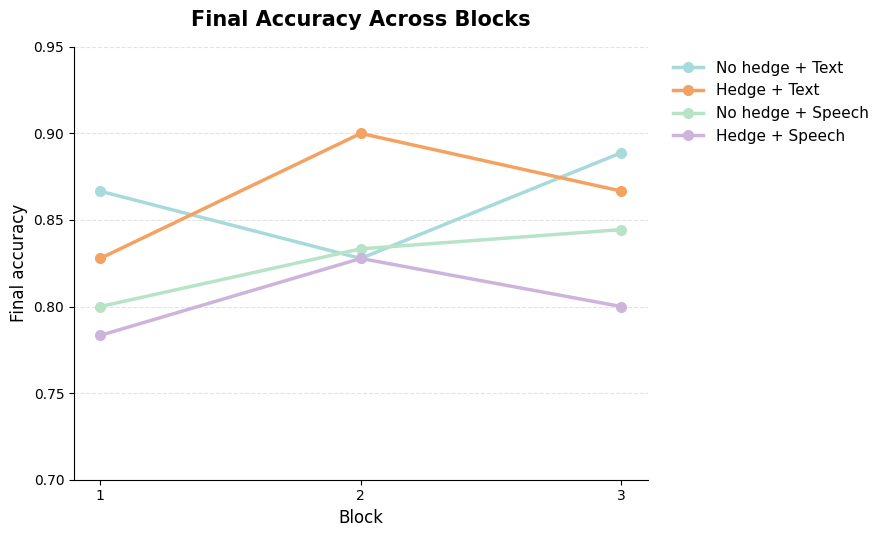

In [20]:
fig, ax = plt.subplots(figsize=(9, 5.5))

for condition in condition_order:
    subset = srq4_table[srq4_table["condition_label"] == condition]
    
    ax.plot(
        subset["block"],
        subset["final_accuracy"],
        marker="o",
        linewidth=2.5,
        markersize=7,
        label=condition,
        color=pastel_colors[condition]
    )

ax.set_title("Final Accuracy Across Blocks", pad=15, fontweight="bold")
ax.set_xlabel("Block")
ax.set_ylabel("Final accuracy")
ax.set_xticks([1, 2, 3])
ax.set_ylim(0.70, 0.95)
ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")

clean_axis(ax)

plt.tight_layout()
plt.savefig("srq4_final_accuracy_across_blocks.png", dpi=300, bbox_inches="tight")
plt.show()

## SRQ4 conclusion

The SRQ4 analysis examines whether reliance behaviour changed across the three task blocks. The evidence is modest. Across all conditions, verification first decreased from 34.9% in block 1 to 32.2% in block 2, and then increased to 36.9% in block 3. This does not indicate a steady increase in caution across blocks, but it does suggest a small late-task increase in verification in block 3.

Final accuracy showed a slightly clearer block-level increase. Accuracy increased from 81.9% in block 1 to 84.7% in block 2 and 85.0% in block 3. This may indicate modest task familiarisation or improved calibration across the session, but the pattern should be interpreted cautiously because the change is small and descriptive.

The condition-level figure shows that the pattern was not consistent across all four conditions. In the text conditions, verification was relatively stable or slightly decreasing across blocks. In the speech conditions, verification increased more clearly toward block 3.

This output is used for Section 4.6 of the thesis. H4 receives limited support.

# Qualitative responses

The open-text responses were used to contextualise the behavioural findings. They were analysed using descriptive qualitative content analysis. Responses were read and grouped into recurring themes related to decision strategy, interpretation of hedges, perceived modality effects, and changes across blocks.

The coding below is keyword-supported and descriptive. It is not intended as a full qualitative interview analysis. A single participant response can contribute to more than one theme when it contains multiple relevant points. Theme frequencies are therefore used as contextual evidence, not as confirmatory statistical evidence.

In [21]:
interviews[[
    "condition_label",
    "interview_strategy",
    "interview_hedges",
    "interview_modality",
    "interview_block_changes"
]].head()

,condition_label,interview_strategy,interview_hedges,interview_modality,interview_block_changes
0,No hedge + Speech,Feedback on verify,As input to validate,No. I read the details.,Use of verify when I doubted.
1,No hedge + Text,Common knowledge and verifying if I had a doubt,Like the assistant was not sure itself,"no, did not have a voice",more aware of the possible wrong anwers
2,No hedge + Text,Primarily my own knowledge but I had to rely o...,"I did not mind that, as most AI come in the fo...","no, it did not.",Not as far as I know
3,No hedge + Text,"I verified quite a lot of the answers, but not...","'I think' is more uncertain, while 'it seems' ...",To be honest I didnt hear a voice...,"Not really, I didnt take breaks I just went th..."
4,Hedge + Text,Whether I already knew the answers upfront or ...,"I notified it, I think it is funny for a syste...","No, I don't think so. Maybe by reading instead...",I do not think so


In [22]:
# Create lowercase versions for simple keyword coding
for col in ["interview_strategy", "interview_hedges", "interview_modality", "interview_block_changes"]:
    interviews[col + "_lower"] = interviews[col].fillna("").str.lower()

# Strategy: own knowledge
interviews["strategy_own_knowledge"] = interviews["interview_strategy_lower"].str.contains(
    "own knowledge|already knew|i knew|common knowledge|knew the answer|my knowledge",
    regex=True
).astype(int)

# Strategy: verify when uncertain / in doubt
interviews["strategy_verify_when_uncertain"] = interviews["interview_strategy_lower"].str.contains(
    "doubt|uncertain|not sure|didn't know|did not know|verify|verified|verification",
    regex=True
).astype(int)

# Hedges noticed as uncertainty
interviews["hedges_noticed_uncertainty"] = interviews["interview_hedges_lower"].str.contains(
    "uncertain|not sure|doubt|doubtful|twijfel|twijfelachtig|less certain|was not sure",
    regex=True
).astype(int)

# Hedges not noticed / ignored / skipped
interviews["hedges_not_noticed_or_ignored"] = interviews["interview_hedges_lower"].str.contains(
    "did not notice|didn't notice|not notice|skipped|ignored|did not see|didn't see|not see",
    regex=True
).astype(int)

# Modality: no effect
interviews["modality_no_effect"] = interviews["interview_modality_lower"].str.contains(
    r"\bno\b|not really|did not|didn't|nee|no effect|no influence|no clear effect|did not influence|didn't influence",
    regex=True
).astype(int)

# Modality: read instead of listened / voice not heard
interviews["modality_read_or_voice_not_heard"] = interviews["interview_modality_lower"].str.contains(
    "read|reading|did not hear|didn't hear|no voice|voice",
    regex=True
).astype(int)

# Block changes: no change
interviews["block_no_change"] = interviews["interview_block_changes_lower"].str.contains(
    r"\bno\b|not really|did not|didn't|nee|not necessarily|no change|did not change|didn't change",
    regex=True
).astype(int)

# Block changes: more aware / changed
interviews["block_more_aware_or_changed"] = interviews["interview_block_changes_lower"].str.contains(
    "more aware|changed|adapt|verify more|more careful|cautious|wrong answers",
    regex=True
).astype(int)

qual_theme_cols = [
    "strategy_own_knowledge",
    "strategy_verify_when_uncertain",
    "hedges_noticed_uncertainty",
    "hedges_not_noticed_or_ignored",
    "modality_no_effect",
    "modality_read_or_voice_not_heard",
    "block_no_change",
    "block_more_aware_or_changed"
]

qual_summary = pd.DataFrame({
    "theme": qual_theme_cols,
    "n_participants": [interviews[col].sum() for col in qual_theme_cols],
    "percentage": [(interviews[col].mean() * 100).round(1) for col in qual_theme_cols]
})

qual_summary

,theme,n_participants,percentage
0,strategy_own_knowledge,33,45.8
1,strategy_verify_when_uncertain,23,31.9
2,hedges_noticed_uncertainty,17,23.6
3,hedges_not_noticed_or_ignored,5,6.9
4,modality_no_effect,37,51.4
5,modality_read_or_voice_not_heard,15,20.8
6,block_no_change,33,45.8
7,block_more_aware_or_changed,3,4.2


## Qualitative modality themes by condition

The general qualitative theme counts show how often participants mentioned that modality had no clear influence, or that they mainly read the displayed answer rather than relying on the spoken output. Because these themes can be mentioned by participants in both text and speech conditions, the counts below split the modality-related themes by experimental condition and modality. This helps avoid interpreting the overall qualitative counts as if they only came from participants in the speech conditions.

In [23]:
# Split modality-related qualitative themes by output modality.
# This avoids interpreting the overall count as if it only came from participants in speech conditions.

if "condition_label" not in interviews.columns or "modality" not in interviews.columns:
    interviews_with_condition = interviews.merge(
        participants[["participant_id", "condition_label", "modality"]],
        on="participant_id",
        how="left"
    )
else:
    interviews_with_condition = interviews.copy()

interviews_with_condition["modality_label"] = interviews_with_condition["modality"].map({
    0: "Text",
    1: "Speech"
})

qual_modality_by_output = interviews_with_condition.groupby("modality_label").agg(
    n_participants=("participant_id", "nunique"),
    modality_no_effect_n=("modality_no_effect", "sum"),
    modality_read_or_voice_not_heard_n=("modality_read_or_voice_not_heard", "sum")
).reset_index()

qual_modality_by_output["modality_no_effect_pct"] = (
    qual_modality_by_output["modality_no_effect_n"] /
    qual_modality_by_output["n_participants"] * 100
).round(1)

qual_modality_by_output["modality_read_or_voice_not_heard_pct"] = (
    qual_modality_by_output["modality_read_or_voice_not_heard_n"] /
    qual_modality_by_output["n_participants"] * 100
).round(1)

qual_modality_by_output

,modality_label,n_participants,modality_no_effect_n,modality_read_or_voice_not_heard_n,modality_no_effect_pct,modality_read_or_voice_not_heard_pct
0,Speech,36,16,9,44.4,25.0
1,Text,36,21,6,58.3,16.7


In [24]:
# Optional: split by full experimental condition

qual_modality_by_condition = interviews_with_condition.groupby("condition_label").agg(
    n_participants=("participant_id", "nunique"),
    modality_no_effect_n=("modality_no_effect", "sum"),
    modality_read_or_voice_not_heard_n=("modality_read_or_voice_not_heard", "sum")
).reset_index()

qual_modality_by_condition["modality_no_effect_pct"] = (
    qual_modality_by_condition["modality_no_effect_n"] /
    qual_modality_by_condition["n_participants"] * 100
).round(1)

qual_modality_by_condition["modality_read_or_voice_not_heard_pct"] = (
    qual_modality_by_condition["modality_read_or_voice_not_heard_n"] /
    qual_modality_by_condition["n_participants"] * 100
).round(1)

qual_modality_by_condition

,condition_label,n_participants,modality_no_effect_n,modality_read_or_voice_not_heard_n,modality_no_effect_pct,modality_read_or_voice_not_heard_pct
0,Hedge + Speech,18,5,3,27.8,16.7
1,Hedge + Text,18,9,2,50.0,11.1
2,No hedge + Speech,18,11,6,61.1,33.3
3,No hedge + Text,18,12,4,66.7,22.2


## Qualitative response conclusion

The qualitative responses provide additional context for interpreting the behavioural results. Because these responses are self-reported reflections, they are interpreted as participants’ perceptions of their own decision-making rather than as direct behavioural evidence.

First, many participants reported that they primarily relied on their own knowledge when deciding whether to accept, reject, or verify an answer. This theme appeared in 33 responses, or 45.8% of participants. This suggests that participants perceived their own knowledge as an important basis for decision-making.

Second, verification was often described as a strategy used when participants were uncertain or in doubt. This appeared in 23 responses, or 31.9% of participants. This aligns with the behavioural finding that incorrect answers were verified more often than correct answers, but it should be interpreted as a self-reported explanation rather than as direct evidence of causality.

Third, hedges were interpreted inconsistently. Some participants noticed phrases such as “I think” or “it seems” and interpreted them as signs of uncertainty. This theme appeared in 17 responses, or 23.6% of participants. At the same time, 5 responses, or 6.9%, indicated that participants did not notice, ignored, or skipped over the hedges. This may help explain why hedging was perceived in the manipulation check but did not consistently change reliance behaviour.

Fourth, many participants reported that modality had no clear influence on their decision-making. This appeared in 37 responses, or 51.4% of all participants. Because this includes both text and speech conditions, it should be interpreted as a general self-reported perception rather than as evidence specific to the speech condition. 

In addition, 15 responses, or 20.8%, suggested that participants mainly read the displayed answer rather than relying on the spoken output, or that the voice was not strongly perceived. This appeared in 6 of 36 text-condition participants and 9 of 36 speech-condition participants. These reflections may help explain why spoken hedges did not increase verification in the speech condition, while also showing that perceived modality influence was limited across the sample as a whole.

Finally, reported changes across blocks were limited. In 33 responses, or 45.8%, participants reported no clear change in strategy across blocks. Only 3 responses, or 4.2%, clearly indicated becoming more aware or changing behaviour. This supports the interpretation that adaptation across blocks was modest rather than strong.

# Supplementary trial-level logistic regression models

The following models are supplementary trial-level logistic regression models. They are used as statistical checks alongside the descriptive condition-level analyses. The dependent variables are binary trial-level outcomes: verification, acceptance, and final accuracy.

Logistic regression is used because each dependent variable is coded as 0 or 1. The models estimate how hedging, correctness, modality, and block are associated with the log-odds of each outcome.

The models use the 2160 trial-level observations as data points. These observations are nested within participants and items, because each participant completed 30 trials and each item appeared across participants. Random intercepts for participants and items are not included because these models are intended as supplementary checks rather than full mixed-effects models, and because the participant-level sample is modest for estimating more complex crossed random-effects interaction models.

The results are therefore interpreted cautiously. Odds ratios are reported as effect size measures. OR values above 1 indicate higher odds of the outcome, while OR values below 1 indicate lower odds of the outcome.

In [25]:
# Prepare trial-level data for supplementary logistic regression models

regression_cols = [
    "verified",
    "accepted",
    "final_accuracy",
    "hedging",
    "correctness",
    "modality",
    "block"
]

regression_data = trials[regression_cols].copy()

for col in regression_cols:
    regression_data[col] = pd.to_numeric(regression_data[col], errors="coerce")

# Drop rows with missing values in any regression variable
regression_data = regression_data.dropna(subset=regression_cols)

print("Regression data shape:", regression_data.shape)
regression_data.head()

Regression data shape: (2160, 7)


,verified,accepted,final_accuracy,hedging,correctness,modality,block
0,0,1,1,0,1,1,1
1,1,0,1,0,0,1,1
2,0,0,1,0,0,1,1
3,0,0,0,0,1,1,1
4,0,0,1,0,0,1,1


In [26]:
import statsmodels.formula.api as smf

# Verification model
model_verify = smf.logit(
    formula="verified ~ hedging * correctness + hedging * modality + block",
    data=regression_data
).fit()

# Acceptance model
model_accept = smf.logit(
    formula="accepted ~ hedging * correctness + hedging * modality + block",
    data=regression_data
).fit()

# Final accuracy model
model_accuracy = smf.logit(
    formula="final_accuracy ~ hedging * correctness + hedging * modality + block",
    data=regression_data
).fit()

Optimization terminated successfully.
         Current function value: 0.629813
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.427045
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.424431
         Iterations 6


In [27]:
# Full model summaries for reproducibility

print("Verification model")
display(model_verify.summary())

print("Acceptance model")
display(model_accept.summary())

print("Final accuracy model")
display(model_accuracy.summary())

Verification model


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               verified   No. Observations:                 2160
Model:                          Logit   Df Residuals:                     2153
Method:                           MLE   Df Model:                            6
Date:                Wed, 03 Jun 2026   Pseudo R-squ.:                 0.02418
Time:                        14:16:01   Log-Likelihood:                -1360.4
converged:                       True   LL-Null:                       -1394.1
Covariance Type:            nonrobust   LLR p-value:                 1.385e-12
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -0.2364      0.172     -1.378      0.168      -0.573       0.100
hedging                 0.2381      0.183      1.299      0.194      -0.121       0.597
correctness            -0.5198      0.138     -3.767      0.000      -0.790      -0.249
hedging:correctness     0.0053      0.196      0.027      0.978      -0.378       0.389
modality               -0.3442      0.130     -2.648      0.008      -0.599      -0.089
hedging:modality       -0.3883      0.184     -2.105      0.035      -0.750      -0.027
block                   0.0475      0.056      0.844      0.399      -0.063       0.158
=======================================================================================
"""

Acceptance model


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               accepted   No. Observations:                 2160
Model:                          Logit   Df Residuals:                     2153
Method:                           MLE   Df Model:                            6
Date:                Wed, 03 Jun 2026   Pseudo R-squ.:                  0.3070
Time:                        14:16:01   Log-Likelihood:                -922.42
converged:                       True   LL-Null:                       -1331.1
Covariance Type:            nonrobust   LLR p-value:                2.686e-173
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -1.0402      0.211     -4.940      0.000      -1.453      -0.628
hedging                 0.0028      0.214      0.013      0.989      -0.416       0.422
correctness             3.1143      0.171     18.173      0.000       2.778       3.450
hedging:correctness    -0.1109      0.240     -0.462      0.644      -0.581       0.360
modality               -0.0728      0.171     -0.427      0.670      -0.407       0.262
hedging:modality       -0.1058      0.238     -0.444      0.657      -0.572       0.361
block                   0.0212      0.073      0.291      0.771      -0.122       0.164
=======================================================================================
"""

Final accuracy model


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:         final_accuracy   No. Observations:                 2160
Model:                          Logit   Df Residuals:                     2153
Method:                           MLE   Df Model:                            6
Date:                Wed, 03 Jun 2026   Pseudo R-squ.:                 0.03868
Time:                        14:16:01   Log-Likelihood:                -916.77
converged:                       True   LL-Null:                       -953.66
Covariance Type:            nonrobust   LLR p-value:                 6.873e-14
=======================================================================================
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               0.9449      0.212      4.456      0.000       0.529       1.361
hedging                 0.1467      0.223      0.658      0.511      -0.290       0.584
correctness             1.0499      0.172      6.115      0.000       0.713       1.386
hedging:correctness    -0.2085      0.241     -0.866      0.386      -0.680       0.263
modality               -0.2780      0.172     -1.619      0.105      -0.615       0.059
hedging:modality       -0.1797      0.240     -0.748      0.455      -0.651       0.291
block                   0.1173      0.073      1.604      0.109      -0.026       0.261
=======================================================================================
"""

In [28]:
# Convert logistic regression coefficients to odds ratios.
# OR values are easier to interpret than log-odds coefficients.

def logistic_summary_with_or(model):
    params = model.params
    conf = model.conf_int()
    pvalues = model.pvalues

    summary = pd.DataFrame({
        "coef": params,
        "OR": np.exp(params),
        "CI_lower": np.exp(conf[0]),
        "CI_upper": np.exp(conf[1]),
        "p": pvalues
    })

    return summary.round(3)

verification_or = logistic_summary_with_or(model_verify)
acceptance_or = logistic_summary_with_or(model_accept)
accuracy_or = logistic_summary_with_or(model_accuracy)

print("Verification model: odds ratios")
display(verification_or)

print("Acceptance model: odds ratios")
display(acceptance_or)

print("Final accuracy model: odds ratios")
display(accuracy_or)

Verification model: odds ratios


,coef,OR,CI_lower,CI_upper,p
Intercept,-0.236,0.789,0.564,1.105,0.168
hedging,0.238,1.269,0.886,1.817,0.194
correctness,-0.520,0.595,0.454,0.779,0.000
hedging:correctness,0.005,1.005,0.685,1.475,0.978
modality,-0.344,0.709,0.549,0.914,0.008
hedging:modality,-0.388,0.678,0.472,0.974,0.035
block,0.047,1.049,0.939,1.171,0.399


Acceptance model: odds ratios


,coef,OR,CI_lower,CI_upper,p
Intercept,-1.040,0.353,0.234,0.534,0.000
hedging,0.003,1.003,0.660,1.524,0.989
correctness,3.114,22.517,16.093,31.505,0.000
hedging:correctness,-0.111,0.895,0.559,1.433,0.644
modality,-0.073,0.930,0.665,1.299,0.670
hedging:modality,-0.106,0.900,0.564,1.435,0.657
block,0.021,1.021,0.886,1.178,0.771


Final accuracy model: odds ratios


,coef,OR,CI_lower,CI_upper,p
Intercept,0.945,2.573,1.698,3.898,0.000
hedging,0.147,1.158,0.748,1.792,0.511
correctness,1.050,2.857,2.041,4.001,0.000
hedging:correctness,-0.209,0.812,0.506,1.301,0.386
modality,-0.278,0.757,0.541,1.060,0.105
hedging:modality,-0.180,0.835,0.522,1.338,0.455
block,0.117,1.124,0.974,1.298,0.109


# Statistical model summary

The full `statsmodels` output is useful for checking coefficients, standard errors, and p-values, but it is not very readable for reporting. The tables above therefore convert the logistic regression coefficients to odds ratios, which are easier to interpret as effect size measures.

The compact summary below highlights the main interpretation of each supplementary model. These models are interpreted alongside the descriptive results rather than as standalone confirmatory evidence.

In [29]:
regression_summary = pd.DataFrame({
    "Outcome": [
        "Verification",
        "Acceptance",
        "Final accuracy"
    ],
    "Main result": [
        "Correctness, modality, and hedging × modality were significant predictors.",
        "Correctness was the dominant significant predictor.",
        "Correctness was the dominant significant predictor."
    ],
    "Key effect sizes": [
        "Correctness OR = 0.60; modality OR = 0.71; hedging × modality OR = 0.68.",
        "Correctness OR = 22.52.",
        "Correctness OR = 2.86."
    ],
    "Interpretation": [
        "Participants were more likely to verify incorrect than correct answers, and the effect of hedging differed between text and speech.",
        "Participants were much more likely to accept correct than incorrect answers; hedging did not significantly reduce acceptance.",
        "Final accuracy was mainly explained by answer correctness; hedging and modality effects were not significant."
    ]
})

regression_summary

,Outcome,Main result,Key effect sizes,Interpretation
0,Verification,"Correctness, modality, and hedging × modality ...",Correctness OR = 0.60; modality OR = 0.71; hed...,Participants were more likely to verify incorr...
1,Acceptance,Correctness was the dominant significant predi...,Correctness OR = 22.52.,Participants were much more likely to accept c...
2,Final accuracy,Correctness was the dominant significant predi...,Correctness OR = 2.86.,Final accuracy was mainly explained by answer ...


## Regression summary conclusion

The supplementary regression models support the descriptive interpretation of the results.

For verification, answer correctness was significant (OR = 0.60, 95% CI [0.45, 0.78], p < .001), indicating that correct-answer trials had lower odds of being verified than incorrect-answer trials. Modality was also significant (OR = 0.71, 95% CI [0.55, 0.91], p = .008), and the hedging by modality interaction was significant (OR = 0.68, 95% CI [0.47, 0.97], p = .035). The hedging by correctness interaction was not significant (OR = 1.01, 95% CI [0.69, 1.48], p = .978), which supports the interpretation that hedging did not selectively increase verification for incorrect answers.

For acceptance, correctness was the dominant predictor (OR = 22.52, 95% CI [16.09, 31.51], p < .001). Hedging, modality, hedging by correctness, hedging by modality, and block were not significant predictors.

For final accuracy, correctness was again the dominant predictor (OR = 2.86, 95% CI [2.04, 4.00], p < .001). Hedging, modality, hedging by correctness, hedging by modality, and block were not significant predictors.

Overall, the clearest statistical result is the modality-dependent effect of hedging on verification behaviour. The models are interpreted as supplementary checks rather than as standalone confirmatory evidence.

In [30]:
hypothesis_summary = pd.DataFrame({
    "Question": ["SRQ1", "SRQ2", "SRQ3", "SRQ4"],
    "Focus": [
        "Verification behaviour",
        "Acceptance of incorrect answers",
        "Interaction between hedging and modality",
        "Adaptation across blocks"
    ],
    "Main result": [
        "Incorrect answers were verified more often than correct answers, but hedging added only a small, non-selective change.",
        "Hedging did not robustly reduce acceptance of incorrect answers, except for a small text-specific reduction.",
        "Hedging increased verification in text but not in speech; the hedging by modality interaction was significant.",
        "Verification and accuracy changed modestly across blocks, especially in speech conditions."
    ],
    "Conclusion": [
        "Weak support",
        "Weak support",
        "Supported",
        "Limited support"
    ]
})

hypothesis_summary

,Question,Focus,Main result,Conclusion
0,SRQ1,Verification behaviour,Incorrect answers were verified more often tha...,Weak support
1,SRQ2,Acceptance of incorrect answers,Hedging did not robustly reduce acceptance of ...,Weak support
2,SRQ3,Interaction between hedging and modality,Hedging increased verification in text but not...,Supported
3,SRQ4,Adaptation across blocks,Verification and accuracy changed modestly acr...,Limited support


# Overall conclusion

This notebook reproduces the data checks, descriptive analyses, figures, qualitative summaries, and supplementary regression models used in the thesis.

The final dataset contained 72 participants and 2160 trial-level observations. The manipulation check showed that hedged answers were perceived as more uncertain and less certain than non-hedged answers, indicating that the wording manipulation was perceived as intended.

The behavioural results showed a reasonable degree of calibration: participants verified incorrect answers more often than correct answers and accepted correct answers much more often than incorrect answers. However, hedging did not produce a strong general improvement in calibrated reliance. For SRQ1, hedging did not selectively increase verification for incorrect answers. For SRQ2, hedging did not robustly reduce acceptance of incorrect answers. For SRQ3, the clearest pattern was modality-dependent: hedging increased verification in text but not in synthetic speech. For SRQ4, there was only modest evidence of change across blocks.

The supplementary logistic regression models support this interpretation. The clearest statistical result was the significant hedging by modality interaction for verification behaviour. The qualitative responses further suggest that many participants relied on their own knowledge, used verification mainly when uncertain, and often perceived modality as having limited influence.

Overall, the notebook supports the thesis conclusion that verbal hedging was perceived as an uncertainty cue, but did not consistently translate into stronger behavioural trust calibration across all conditions.